In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_5.0/fold0_0.5_genomic_windows_table_results.tsv", sep="\t")

fold0_05["fold"] = [0 for i in range(len(fold0_05))]
fold0_05["target"] = [-0.5 for i in range(len(fold0_05))]

In [3]:
fold1_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_5.0/fold1_0.5_genomic_windows_table_results.tsv", sep="\t")

fold1_05["fold"] = [1 for i in range(len(fold1_05))]
fold1_05["target"] = [-0.5 for i in range(len(fold1_05))]

In [4]:
fold2_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountain/lambda/lambda_5.0/fold2_0.5_genomic_windows_table_results.tsv", sep="\t")

fold2_05["fold"] = [0 for i in range(len(fold2_05))]
fold2_05["target"] = [-0.5 for i in range(len(fold2_05))]

In [5]:
df = pd.concat([fold0_05, fold1_05, fold2_05], ignore_index=True)

In [ ]:
df.columns

In [6]:
df["anti_diag30_diff"] = df["ed_anti_diag30"] - df["og_anti_diag30"]

In [ ]:
len(df)

In [7]:
df = df[df["num_edits"] > 0]

In [ ]:
len(df)

In [8]:
# optimizations successful in anti_diag30_diff > 0.0
df = df[df["anti_diag30_diff"] > 0.0]

In [9]:
df["FIMO_max_diff"] = df["FIMO_max"] - df["init_max_FIMO"]
df["FIMO_sum_diff"] = df["FIMO_sum"] - df["init_sum_FIMO"]
df["CTCF_num_diff"] = df["CTCFs_num"] - df["init_CTCFs_num"]

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df["og_anti_diag30"].mean()

-0.017313208548571428

In [12]:
df["ed_anti_diag30"].mean()

0.26589828661785714

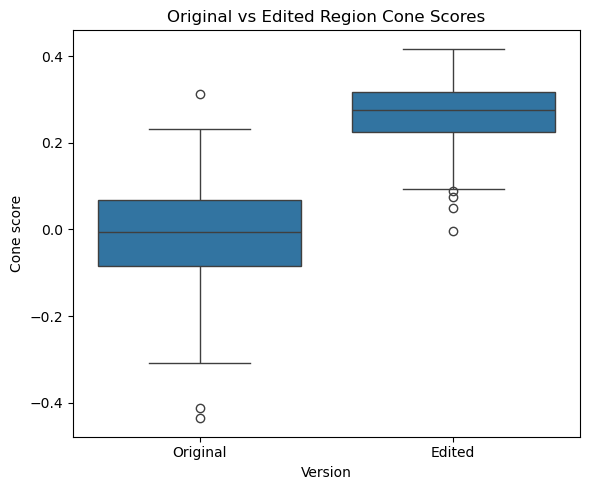

In [13]:
# Reshape to long format
plot_df = pd.melt(df, 
                  value_vars=['og_anti_diag30', 'ed_anti_diag30'],
                  var_name='Version', 
                  value_name='Score')

# Rename for prettier labels (optional)
plot_df['Version'] = plot_df['Version'].replace({
    'og_anti_diag30': 'Original',
    'ed_anti_diag30': 'Edited'
})

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Version', y='Score', data=plot_df)
plt.ylabel('Cone score')
plt.title('Original vs Edited Region Cone Scores')
plt.tight_layout()
plt.show()


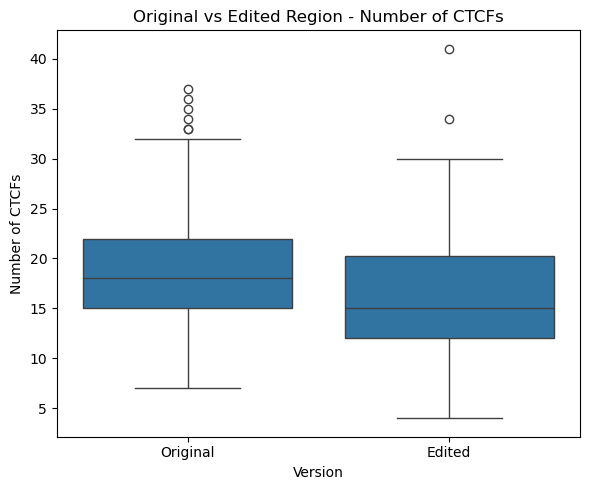

In [14]:
# Reshape to long format
plot_df = pd.melt(df, 
                  value_vars=['init_CTCFs_num', 'CTCFs_num'],
                  var_name='Version', 
                  value_name='Score')

# Rename for prettier labels (optional)
plot_df['Version'] = plot_df['Version'].replace({
    'init_CTCFs_num': 'Original',
    'CTCFs_num': 'Edited'
})

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Version', y='Score', data=plot_df)
plt.ylabel('Number of CTCFs')
plt.title('Original vs Edited Region - Number of CTCFs')
plt.tight_layout()
plt.show()

In [15]:
df["init_CTCFs_num"].mean(), df["CTCFs_num"].mean()

(18.807142857142857, 16.55)

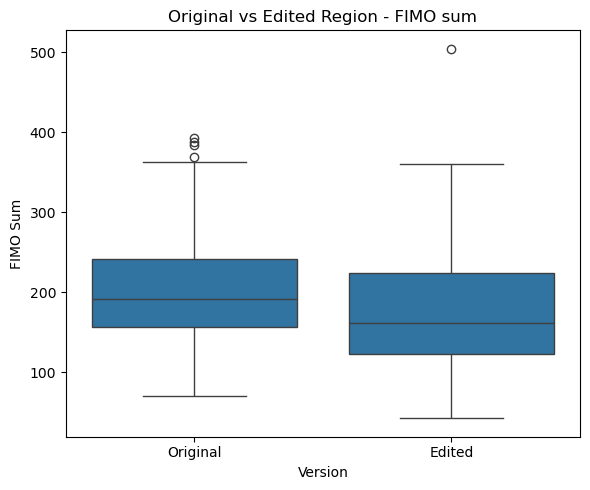

In [16]:
# Reshape to long format
plot_df = pd.melt(df, 
                  value_vars=['init_sum_FIMO', 'FIMO_sum'],
                  var_name='Version', 
                  value_name='Score')

# Rename for prettier labels (optional)
plot_df['Version'] = plot_df['Version'].replace({
    'init_sum_FIMO': 'Original',
    'FIMO_sum': 'Edited'
})

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Version', y='Score', data=plot_df)
plt.ylabel('FIMO Sum')
plt.title('Original vs Edited Region - FIMO sum')
plt.tight_layout()
plt.show()

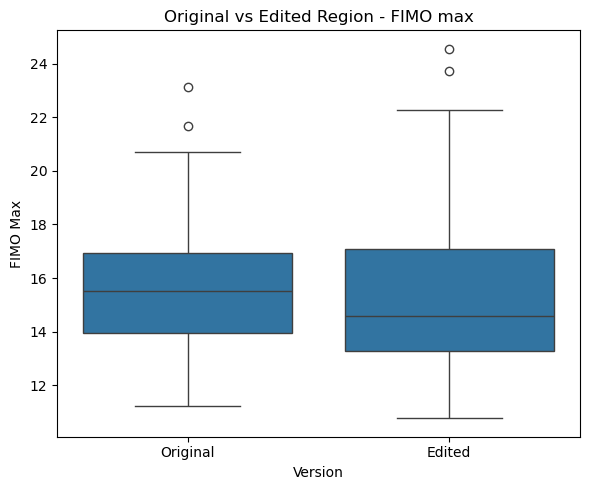

In [17]:
# Reshape to long format
plot_df = pd.melt(df, 
                  value_vars=['init_max_FIMO', 'FIMO_max'],
                  var_name='Version', 
                  value_name='Score')

# Rename for prettier labels (optional)
plot_df['Version'] = plot_df['Version'].replace({
    'init_max_FIMO': 'Original',
    'FIMO_max': 'Edited'
})

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Version', y='Score', data=plot_df)
plt.ylabel('FIMO Max')
plt.title('Original vs Edited Region - FIMO max')
plt.tight_layout()
plt.show()

In [18]:
import ast

# Convert stringified lists back into Python lists
df["removed_positions"] = df["removed_positions"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [19]:
df["removed_strands"] = df["removed_strands"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [20]:
bin_size = 2048
n_bins = 50

# Flatten all removed positions across sequences into bin indices
all_removed_bins = []
for positions in df["removed_positions"]:
    for (start, end) in positions:
        bin_idx = start // bin_size
        if 0 <= bin_idx < n_bins:
            all_removed_bins.append(bin_idx)

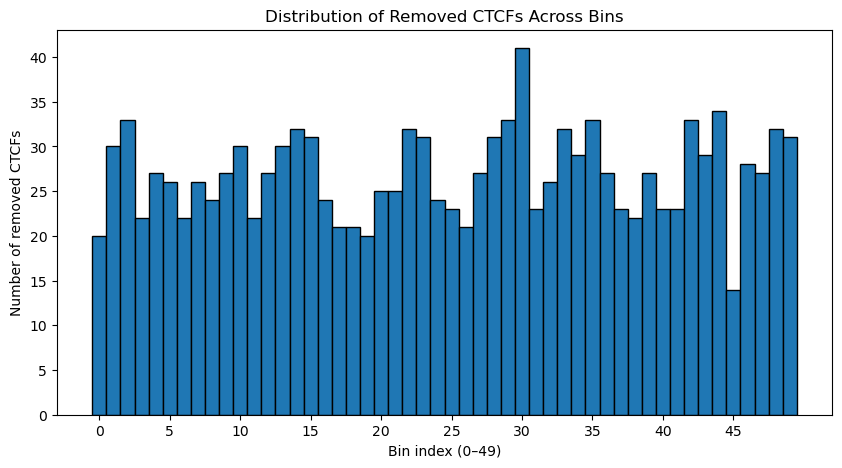

In [21]:
# Create histogram
plt.figure(figsize=(10,5))
plt.hist(all_removed_bins, bins=range(n_bins+1), edgecolor='black', align='left')
plt.xlabel("Bin index (0–49)")
plt.ylabel("Number of removed CTCFs")
plt.title("Distribution of Removed CTCFs Across Bins")
plt.xticks(range(0, n_bins, 5))  # show fewer x-ticks for readability
plt.show()

In [22]:
removed_bins_plus = []
removed_bins_minus = []

# Iterate over rows to assign positions to + or - bins
for positions, strands in zip(df["removed_positions"], df["removed_strands"]):
    for (pos, _), strand in zip(positions, strands):
        bin_idx = pos // bin_size
        if 0 <= bin_idx < n_bins:
            if strand == "+":
                removed_bins_plus.append(bin_idx)
            elif strand == "-":
                removed_bins_minus.append(bin_idx)

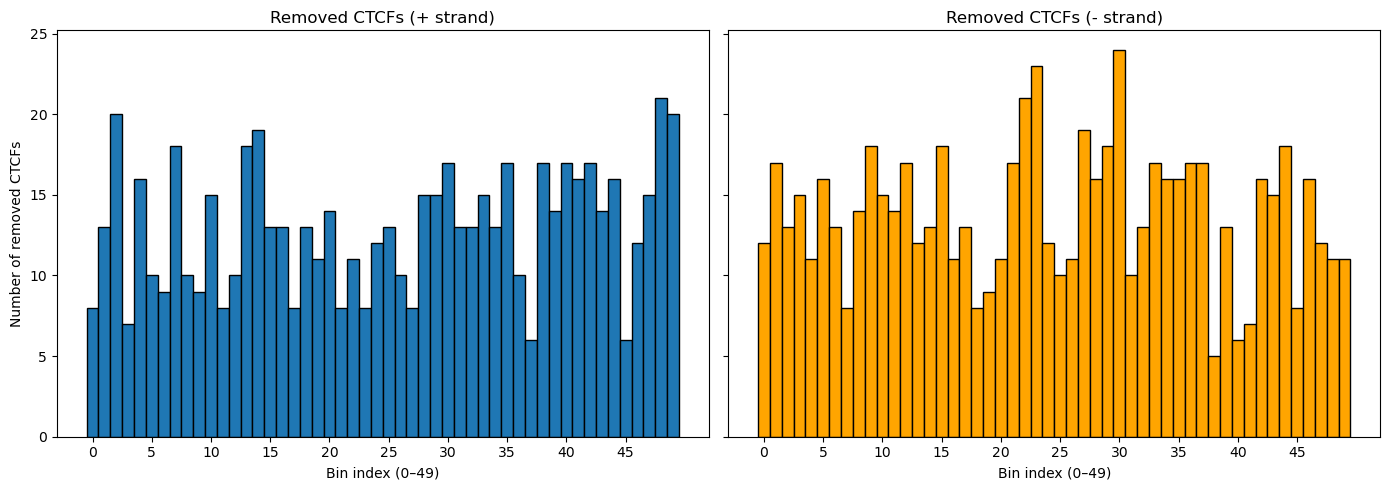

In [23]:
# Plot side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(removed_bins_plus, bins=range(n_bins+1), edgecolor='black', align='left')
axes[0].set_title("Removed CTCFs (+ strand)")
axes[0].set_xlabel("Bin index (0–49)")
axes[0].set_ylabel("Number of removed CTCFs")
axes[0].set_xticks(range(0, n_bins, 5))

axes[1].hist(removed_bins_minus, bins=range(n_bins+1), edgecolor='black', align='left', color="orange")
axes[1].set_title("Removed CTCFs (- strand)")
axes[1].set_xlabel("Bin index (0–49)")
axes[1].set_xticks(range(0, n_bins, 5))

plt.tight_layout()
plt.show()

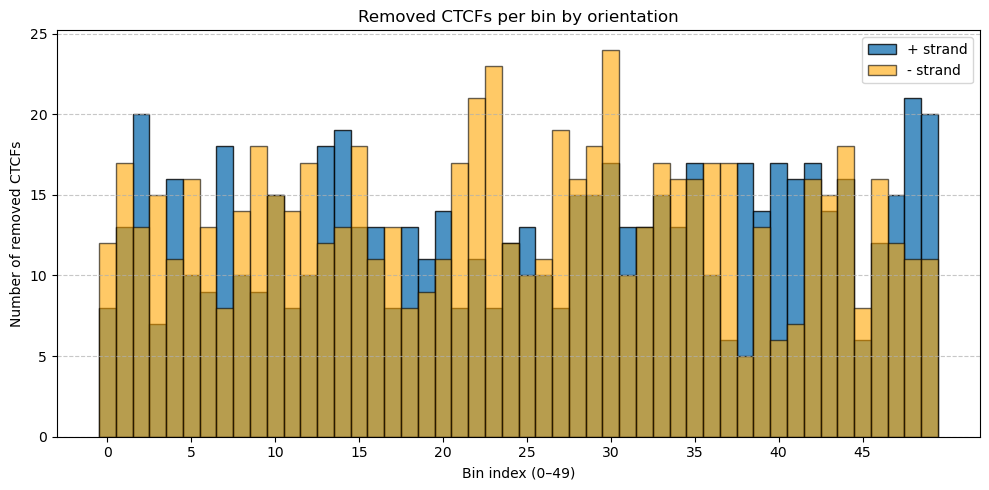

In [24]:
plt.figure(figsize=(10,5))
bins = range(n_bins+1)

plt.hist(removed_bins_plus, bins=bins, alpha=0.8, label='+ strand', edgecolor='black', align='left')
plt.hist(removed_bins_minus, bins=bins, alpha=0.6, label='- strand', edgecolor='black', align='left', color='orange')

plt.xlabel("Bin index (0–49)")
plt.ylabel("Number of removed CTCFs")
plt.title("Removed CTCFs per bin by orientation")
plt.xticks(range(0, n_bins, 5))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
len(df)

In [ ]:
df.columns

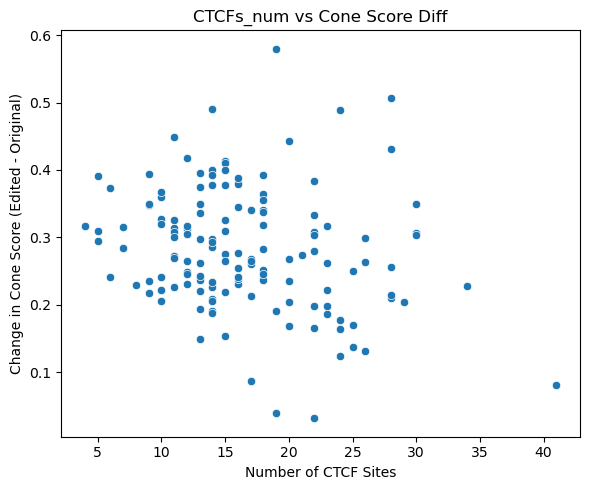

In [25]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='CTCFs_num', y='anti_diag30_diff')

plt.xlabel('Number of CTCF Sites')
plt.ylabel('Change in Cone Score (Edited - Original)')
plt.title('CTCFs_num vs Cone Score Diff')
plt.tight_layout()
plt.show()

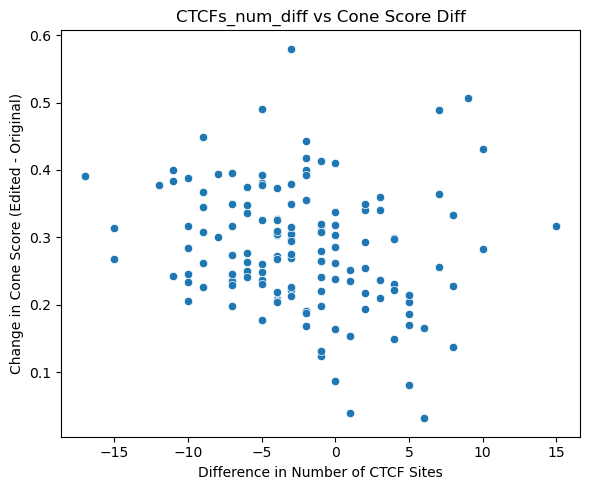

In [26]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='CTCF_num_diff', y='anti_diag30_diff')

plt.xlabel('Difference in Number of CTCF Sites')
plt.ylabel('Change in Cone Score (Edited - Original)')
plt.title('CTCFs_num_diff vs Cone Score Diff')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='CTCF_num_diff', y='ed_anti_diag30')

plt.xlabel('Difference in Number of CTCF Sites')
plt.ylabel('Cone Score')
plt.title('CTCFs_num_diff vs Cone Score')
plt.tight_layout()
plt.show()

In [ ]:
# Basic scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='FIMO_sum', y='anti_diag30_diff')

plt.xlabel('Sum of FIMO scores')
plt.ylabel('Change in Cone Score (Edited - Original)')
plt.title('FIMO_sum vs Cone Score Diff')
plt.tight_layout()
plt.show()

In [ ]:
# Basic scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='FIMO_sum_diff', y='anti_diag30_diff')

plt.xlabel('Difference in Sum of FIMO scores')
plt.ylabel('Change in Cone Score (Edited - Original)')
plt.title('FIMO_sum_diff vs Cone Score Diff')
plt.tight_layout()
plt.show()

In [ ]:
# Basic scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='FIMO_max_diff', y='anti_diag30_diff')

plt.xlabel('Difference in Max of FIMO scores')
plt.ylabel('Change in Cone Score (Edited - Original)')
plt.title('FIMO_max_diff vs Cone Score Diff')
plt.tight_layout()
plt.show()

In [ ]:
# Basic scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='FIMO_max', y='anti_diag30_diff')

plt.xlabel('Max of FIMO scores')
plt.ylabel('Change in Cone Score (Edited - Original)')
plt.title('FIMO_max vs Cone Score Diff')
plt.tight_layout()
plt.show()

In [ ]:
# Basic scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='FIMO_max', y='ed_anti_diag30')

plt.xlabel('Max of FIMO scores')
plt.ylabel('Cone Score')
plt.title('FIMO_max vs Cone Score')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(df['num_edits'].dropna(), bins=30, kde=False)

plt.xlabel('num_edits')
plt.ylabel('Count')
plt.title('Distribution of number of edits (within 100kb)')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(df['last_accepted_step'].dropna(), bins=30, kde=False)

plt.xlabel('last_accepted_step')
plt.ylabel('Count')
plt.title('Distribution of last indices with accepted edits')
plt.tight_layout()
plt.show()

In [ ]:
# Reshape to long format for plotting
plot_df = pd.melt(df,
                  value_vars=['GC_slice', 'GC_slice_edited'],
                  var_name='Version',
                  value_name='GC Content')

# Optional: rename columns for prettier x-axis labels
plot_df['Version'] = plot_df['Version'].replace({
    'GC_slice': 'Original',
    'GC_slice_edited': 'Edited'
})

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(data=plot_df, x='Version', y='GC Content')
plt.ylabel('GC Content')
plt.title('GC Content: Original vs Edited Slice')
plt.tight_layout()
plt.show()

In [ ]:
import ast

In [ ]:
gc_og = df["per_bin_GC_og"].apply(ast.literal_eval)
gc_ed = df["per_bin_GC_ed"].apply(ast.literal_eval)

In [ ]:
gc_og_array = np.array(gc_og.tolist())  # shape: (n_regions, 50)
gc_ed_array = np.array(gc_ed.tolist())

In [ ]:
avg_gc_orig = gc_og_array.mean(axis=0)
avg_gc_edit = gc_ed_array.mean(axis=0)

In [ ]:
# Plot
plt.figure(figsize=(10, 5))
bins = np.arange(len(avg_gc_orig))

plt.plot(bins, avg_gc_orig, label="Original", marker='o')
plt.plot(bins, avg_gc_edit, label="Edited", marker='x')
plt.xlabel("Bin Index")
plt.ylabel("Average GC Content")
plt.title("Average GC Content Per Bin (Before vs After Optimization)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Count occurrences of each orientation string
orientation_counts = df["orientation"].value_counts()

# Select top 25
top_orientations = orientation_counts.head(25)

In [ ]:
# Plot
plt.figure(figsize=(12, 6))
top_orientations.plot(kind="bar")
plt.xlabel("Orientation String")
plt.ylabel("Frequency")
plt.title("Top 25 Most Common CTCF Orientation Patterns")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
df.columns

In [ ]:
bin_CTCFs = df["bin_CTCFs"].apply(ast.literal_eval)

In [ ]:
n_bins = 51
n_rows = len(df)

forward_counts = np.zeros(n_bins)
reverse_counts = np.zeros(n_bins)
both_counts = np.zeros(n_bins)

for ctcf_list in bin_CTCFs:
    for bin_idx, orientation in ctcf_list:
        if '+' in orientation and '-' in orientation:
            both_counts[bin_idx] += 1
        elif '+' in orientation:
            forward_counts[bin_idx] += 1
        elif '-' in orientation:
            reverse_counts[bin_idx] += 1

# Normalize to fractions
forward_fraction = forward_counts / n_rows
reverse_fraction = reverse_counts / n_rows
both_fraction = both_counts / n_rows

In [ ]:
# Plot
bins = np.arange(n_bins)
plt.figure(figsize=(12, 5))
plt.plot(bins, forward_fraction, label='Forward (+)', color='blue')
plt.plot(bins, reverse_fraction, label='Reverse (-)', color='red')
plt.plot(bins, both_fraction, label='Both (+/-)', color='purple')

plt.xlabel('Bin Position')
plt.ylabel('Fraction of Sequences')
plt.title('CTCF Orientation per Bin Position')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
n_rows = len(df)
n_bins = 51
orientation_matrix = np.zeros((n_rows, n_bins), dtype=int)

for row_idx, ctcf_list in enumerate(bin_CTCFs):
    bin_to_orientation = {}
    for bin_idx, orientation in ctcf_list:
        if bin_idx not in bin_to_orientation:
            bin_to_orientation[bin_idx] = set()
        if '+' in orientation:
            bin_to_orientation[bin_idx].add('+')
        if '-' in orientation:
            bin_to_orientation[bin_idx].add('-')

    for bin_idx, dirs in bin_to_orientation.items():
        if '+' in dirs and '-' in dirs:
            orientation_matrix[row_idx, bin_idx] = 3
        elif '+' in dirs:
            orientation_matrix[row_idx, bin_idx] = 1
        elif '-' in dirs:
            orientation_matrix[row_idx, bin_idx] = 2

In [ ]:
orientation_matrix = orientation_matrix[:, :50]

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cmap = mcolors.ListedColormap(['white', 'red', 'blue', 'purple'])
bounds = [0, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

In [ ]:
plt.figure(figsize=(12, 8))
plt.imshow(orientation_matrix, aspect='auto', cmap=cmap, norm=norm)
plt.colorbar(ticks=[0, 1, 2, 3], label='Motif Orientation')
plt.clim(-0.5, 3.5)
plt.xlabel('Bin Index')
plt.ylabel('Sequence Index')
plt.title('CTCF Orientation Across Sequences and Bins')
plt.tight_layout()
plt.show()